In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [40]:

file_path = r"D:\Thesis_Speed_Model\data\Raw\Semifinal data.xlsx"
df = pd.read_excel(file_path)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape of dataset: (87, 9)


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type
0,1,35.00,8.540,30.0,5.5,1.0,Paved,1.0,Paved
1,2,39.00,6.420,35.0,5.5,1.0,Paved,1.0,Paved
2,3,37.00,2.420,75.0,5.5,1.0,Gravel,1.0,Gravel
3,4,46.35,4.140,75.0,5.5,1.0,Paved,1.0,Paved
4,5,40.15,5.235,42.0,7.0,1.0,Paved,1.0,Gravel


In [41]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics for numeric columns:")
display(df.describe())

print("\nBasic information about non-numeric columns:")
display(df.select_dtypes(include="object").describe())

Column names:
['SN', 'V85 Speed', 'Gradient', 'Radius of Curve', 'Carriageway Width', 'Left Shoulder Width', 'Left Shoulder Type', 'Right Shoulder Width', 'Right Shoulder Type']

Data types:
SN                        int64
V85 Speed               float64
Gradient                float64
Radius of Curve         float64
Carriageway Width       float64
Left Shoulder Width     float64
Left Shoulder Type          str
Right Shoulder Width    float64
Right Shoulder Type         str
dtype: object

Basic statistics for numeric columns:


D:\Thesis_Speed_Model\env\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
D:\Thesis_Speed_Model\env\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width
count,87.000000,87.000000,87.000000,87.0,87.000000,87.000000,87.000000
mean,44.000000,47.547011,3.792672,inf,6.821839,0.514368,0.474138
std,25.258662,10.964723,2.323363,NaN,0.499866,0.407695,0.426305
min,1.000000,24.000000,0.100000,15.0,5.500000,0.000000,0.000000
25%,22.500000,40.575000,1.425000,52.5,7.000000,0.000000,0.000000
50%,44.000000,48.000000,3.980000,110.0,7.000000,0.500000,0.500000
75%,65.500000,56.600000,5.922500,NaN,7.000000,1.000000,1.000000
max,87.000000,72.000000,8.540000,inf,8.000000,1.000000,1.000000



Basic information about non-numeric columns:


C:\Users\ACER\AppData\Local\Temp\ipykernel_4972\2253084686.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.select_dtypes(include="object").describe())


,Left Shoulder Type,Right Shoulder Type
count,87,87
unique,3,3
top,Paved,Paved
freq,33,37


In [42]:
missing_table = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values
})

print("Missing value table:")
display(missing_table)

Missing value table:


,Column,Missing Values
0,SN,0
1,V85 Speed,0
2,Gradient,0
3,Radius of Curve,0
4,Carriageway Width,0
5,Left Shoulder Width,0
6,Left Shoulder Type,0
7,Right Shoulder Width,0
8,Right Shoulder Type,0


In [43]:
print("Unique values in Left Shoulder Type:")
print(df["Left Shoulder Type"].unique())

print("\nUnique values in Right Shoulder Type:")
print(df["Right Shoulder Type"].unique())

print("\nUnique values in Radius of Curve:")
print(df["Radius of Curve"].unique())

Unique values in Left Shoulder Type:
<StringArray>
['Paved', 'Gravel', 'Absent']
Length: 3, dtype: str

Unique values in Right Shoulder Type:
<StringArray>
['Paved', 'Gravel', 'Absent']
Length: 3, dtype: str

Unique values in Radius of Curve:
[ 30.  35.  75.  42.  60.  70.  inf  76. 210. 100. 110.  50. 120.  45.
  90. 145.  33.  15. 200.  28.  83.  95. 180. 220. 250. 300.  55. 150.
  20.  40.]


In [44]:
df = df.copy()

# make sure radius column is treated as text first
df["Radius of Curve"] = df["Radius of Curve"].astype(str).str.strip()

# create section type
df["Section Type"] = np.where(
    df["Radius of Curve"].str.lower() == "infinity",
    "Tangent",
    "Curve"
)

# create numeric radius
df["Radius Numeric"] = df["Radius of Curve"].replace("infinity", np.inf)
df["Radius Numeric"] = pd.to_numeric(df["Radius Numeric"], errors="coerce")

# create curvature = 1 / radius
df["Curvature"] = np.where(
    np.isinf(df["Radius Numeric"]),
    0,
    1 / df["Radius Numeric"]
)

print("New variables created successfully.")
display(df.head())

New variables created successfully.


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type,Section Type,Radius Numeric,Curvature
0,1,35.00,8.540,30.0,5.5,1.0,Paved,1.0,Paved,Curve,30.0,0.033333
1,2,39.00,6.420,35.0,5.5,1.0,Paved,1.0,Paved,Curve,35.0,0.028571
2,3,37.00,2.420,75.0,5.5,1.0,Gravel,1.0,Gravel,Curve,75.0,0.013333
3,4,46.35,4.140,75.0,5.5,1.0,Paved,1.0,Paved,Curve,75.0,0.013333
4,5,40.15,5.235,42.0,7.0,1.0,Paved,1.0,Gravel,Curve,42.0,0.023810


In [45]:
df["Radius Summary"] = df["Radius Numeric"].replace(np.inf, np.nan)

numeric_summary = df[[
    "V85 Speed",
    "Gradient",
    "Radius Summary",
    "Curvature",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]].describe()

print("Descriptive statistics table:")
display(numeric_summary)

Descriptive statistics table:


,V85 Speed,Gradient,Radius Summary,Curvature,Carriageway Width,Left Shoulder Width,Right Shoulder Width
count,87.000000,87.000000,60.000000,87.000000,87.000000,87.000000,87.000000
mean,47.547011,3.792672,96.283333,0.013527,6.821839,0.514368,0.474138
std,10.964723,2.323363,76.174219,0.017015,0.499866,0.407695,0.426305
min,24.000000,0.100000,15.000000,0.000000,5.500000,0.000000,0.000000
25%,40.575000,1.425000,40.000000,0.000000,7.000000,0.000000,0.000000
50%,48.000000,3.980000,72.500000,0.009091,7.000000,0.500000,0.500000
75%,56.600000,5.922500,120.000000,0.019091,7.000000,1.000000,1.000000
max,72.000000,8.540000,300.000000,0.066667,8.000000,1.000000,1.000000


In [46]:
left_shoulder_freq = df["Left Shoulder Type"].value_counts().reset_index()
left_shoulder_freq.columns = ["Left Shoulder Type", "Count"]

right_shoulder_freq = df["Right Shoulder Type"].value_counts().reset_index()
right_shoulder_freq.columns = ["Right Shoulder Type", "Count"]

section_type_freq = df["Section Type"].value_counts().reset_index()
section_type_freq.columns = ["Section Type", "Count"]

print("Left Shoulder Type Frequency Table")
display(left_shoulder_freq)

print("Right Shoulder Type Frequency Table")
display(right_shoulder_freq)

print("Section Type Frequency Table")
display(section_type_freq)

Left Shoulder Type Frequency Table


,Left Shoulder Type,Count
0,Paved,33
1,Absent,28
2,Gravel,26


Right Shoulder Type Frequency Table


,Right Shoulder Type,Count
0,Paved,37
1,Absent,34
2,Gravel,16


Section Type Frequency Table


,Section Type,Count
0,Curve,87


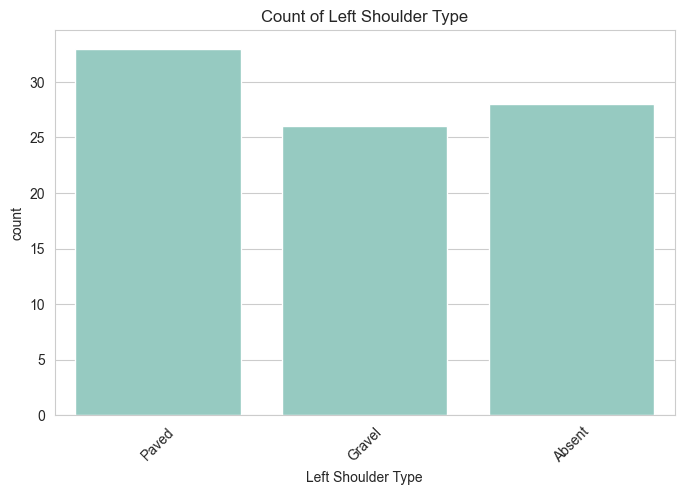

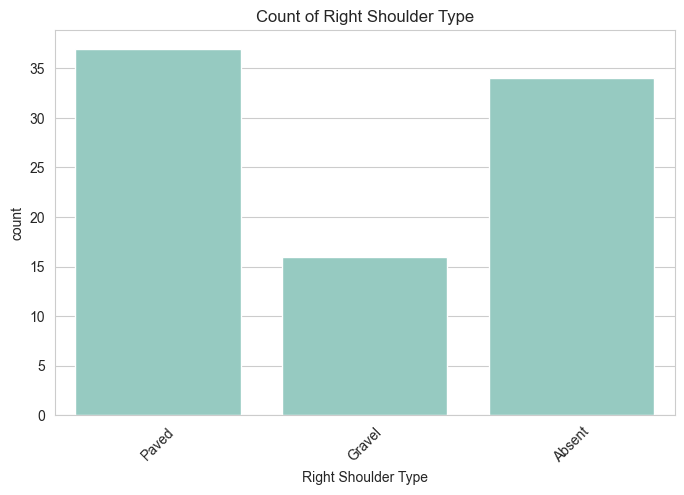

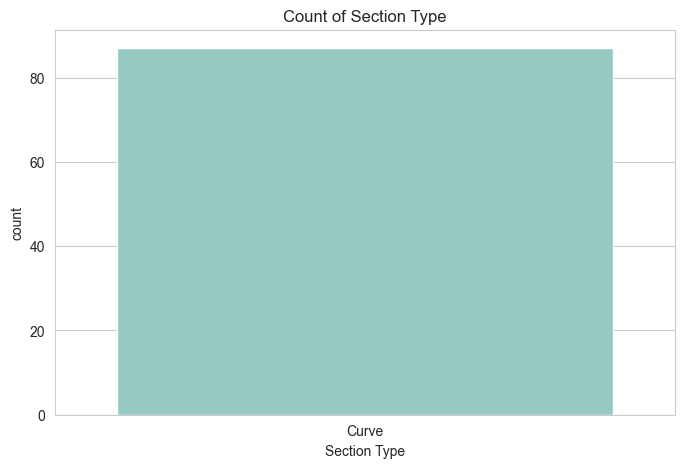

In [47]:
plt.figure()
sns.countplot(x=df["Left Shoulder Type"])
plt.title("Count of Left Shoulder Type")
plt.xticks(rotation=45)
plt.show()

plt.figure()
sns.countplot(x=df["Right Shoulder Type"])
plt.title("Count of Right Shoulder Type")
plt.xticks(rotation=45)
plt.show()

plt.figure()
sns.countplot(x=df["Section Type"])
plt.title("Count of Section Type")
plt.show()

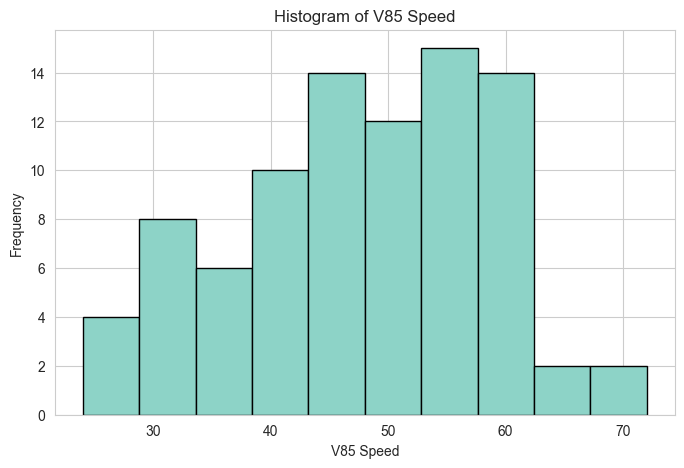

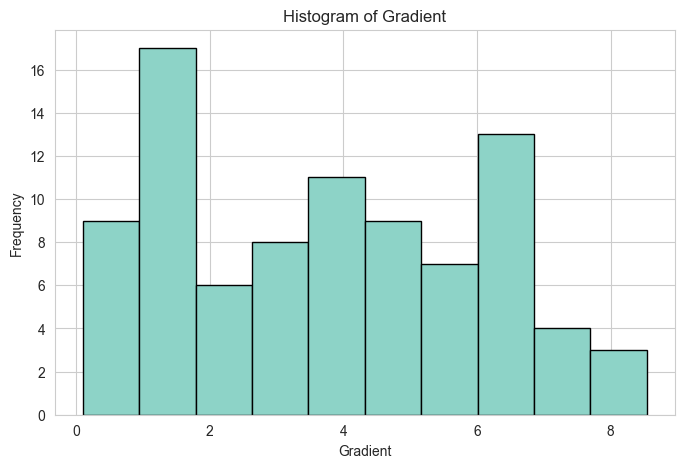

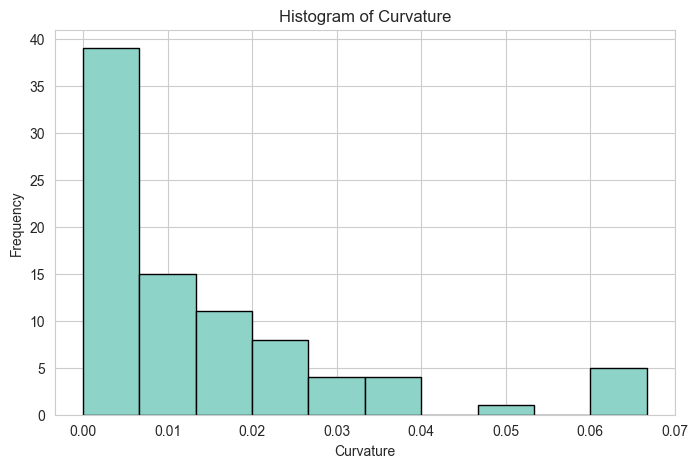

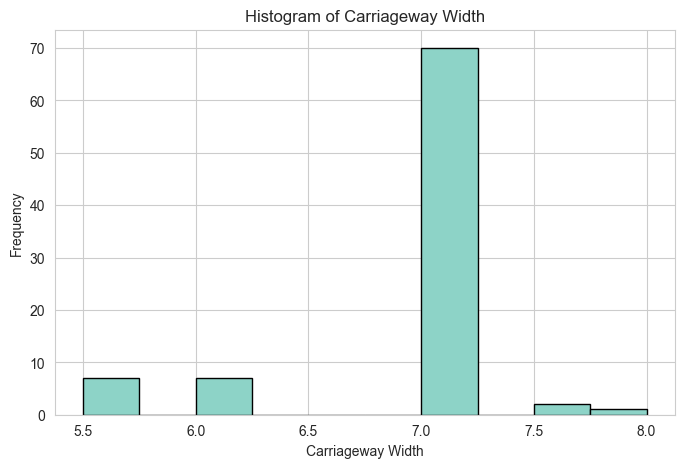

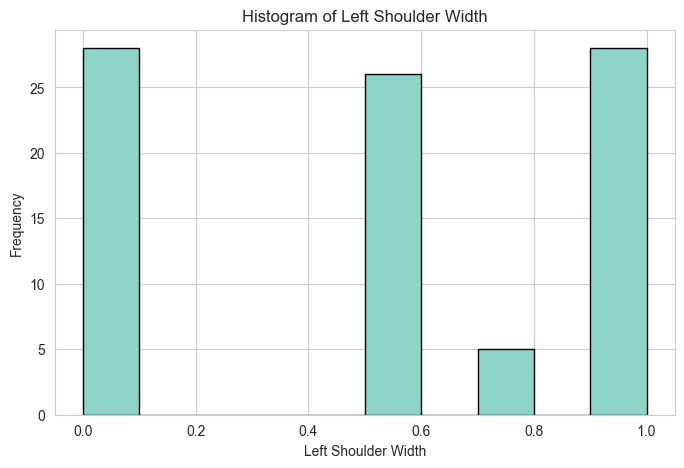

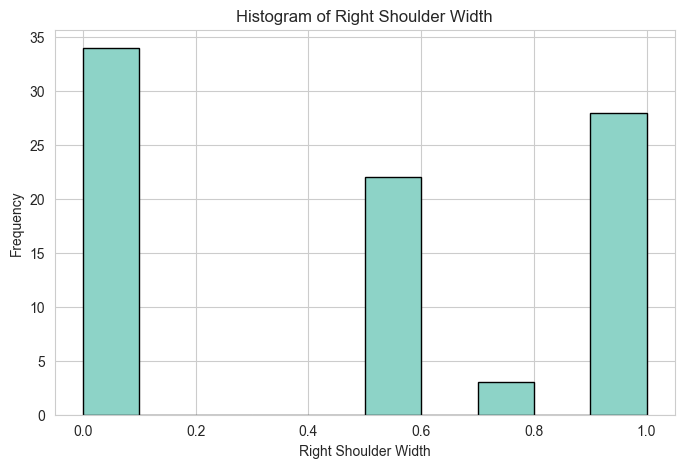

In [48]:
numeric_cols = [
    "V85 Speed",
    "Gradient",
    "Curvature",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]

for col in numeric_cols:
    plt.figure()
    plt.hist(df[col], bins=10, edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

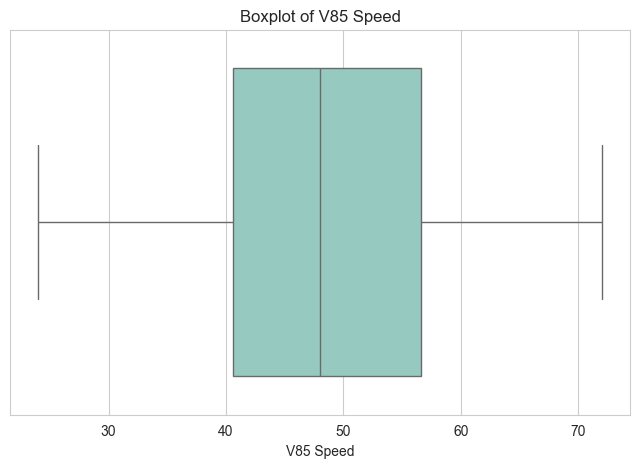

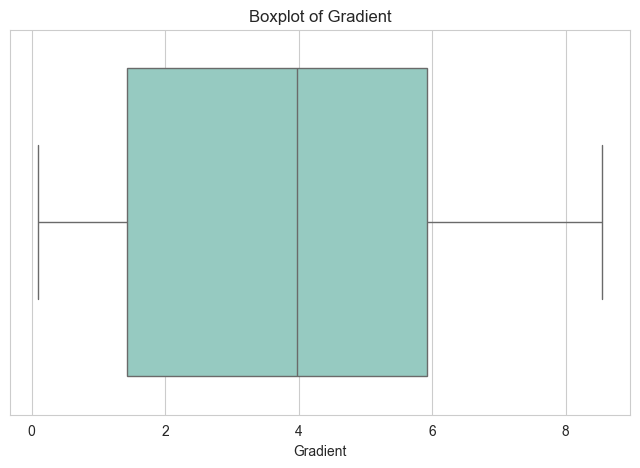

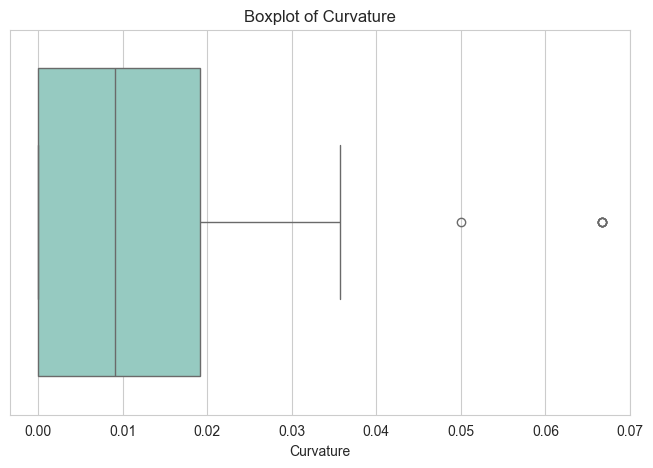

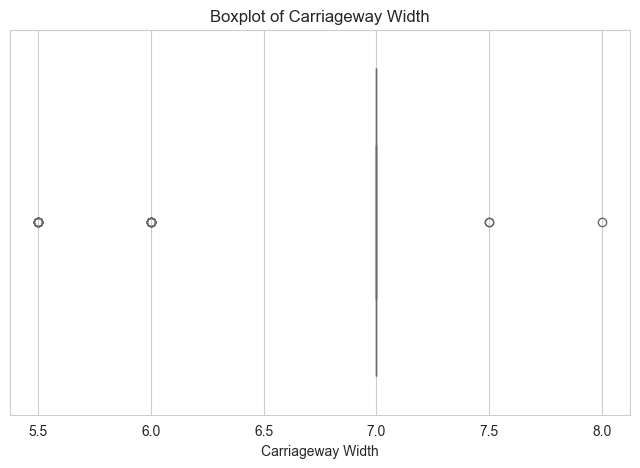

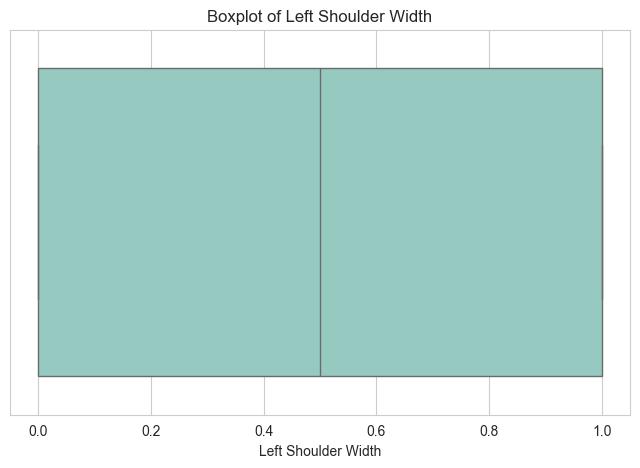

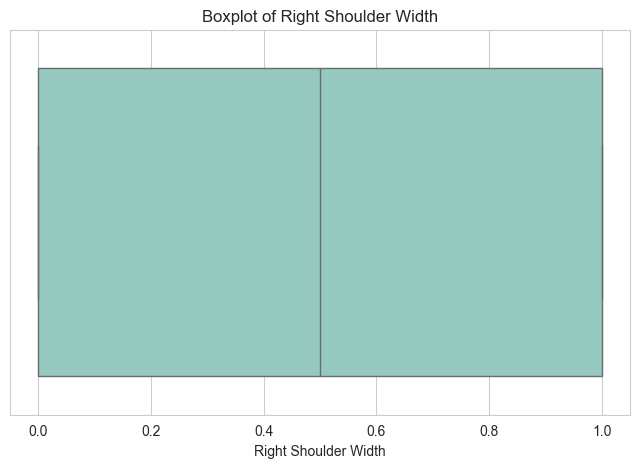

In [49]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

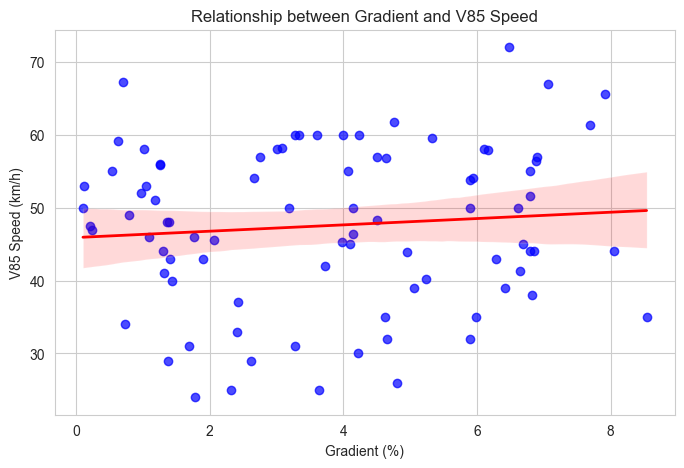

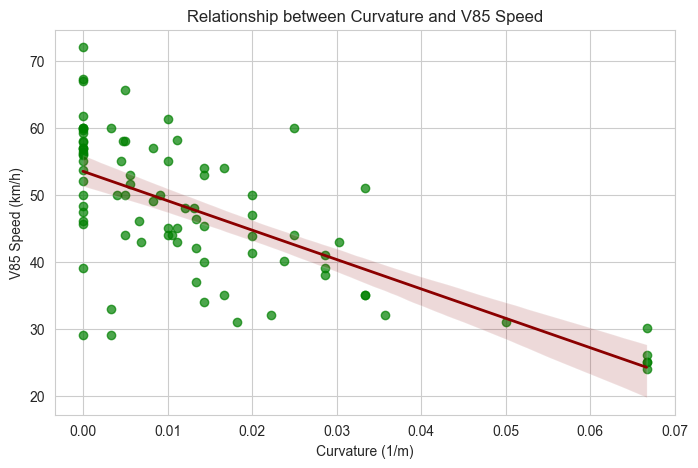

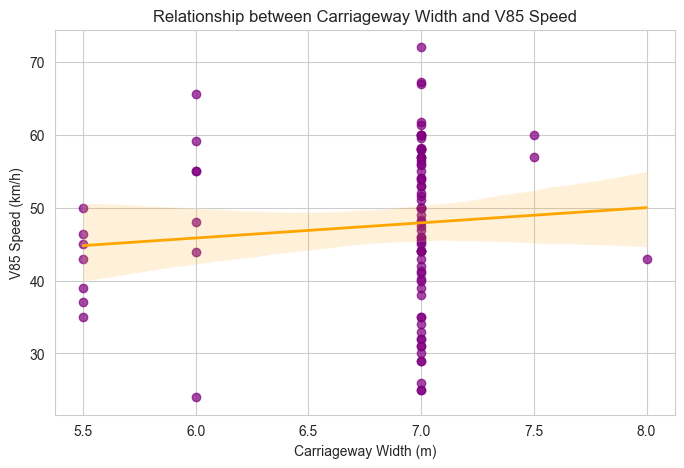

In [50]:
sns.set_style("whitegrid")

# Gradient vs Speed
plt.figure(figsize=(8, 5))
sns.regplot(
    x=df["Gradient"],
    y=df["V85 Speed"],
    scatter_kws={"color": "blue", "alpha": 0.7},
    line_kws={"color": "red", "linewidth": 2}
)
plt.title("Relationship between Gradient and V85 Speed")
plt.xlabel("Gradient (%)")
plt.ylabel("V85 Speed (km/h)")
plt.show()


# Curvature vs Speed
plt.figure(figsize=(8, 5))
sns.regplot(
    x=df["Curvature"],
    y=df["V85 Speed"],
    scatter_kws={"color": "green", "alpha": 0.7},
    line_kws={"color": "darkred", "linewidth": 2}
)
plt.title("Relationship between Curvature and V85 Speed")
plt.xlabel("Curvature (1/m)")
plt.ylabel("V85 Speed (km/h)")
plt.show()


# Carriageway Width vs Speed
plt.figure(figsize=(8, 5))
sns.regplot(
    x=df["Carriageway Width"],
    y=df["V85 Speed"],
    scatter_kws={"color": "purple", "alpha": 0.7},
    line_kws={"color": "orange", "linewidth": 2}
)
plt.title("Relationship between Carriageway Width and V85 Speed")
plt.xlabel("Carriageway Width (m)")
plt.ylabel("V85 Speed (km/h)")
plt.show()

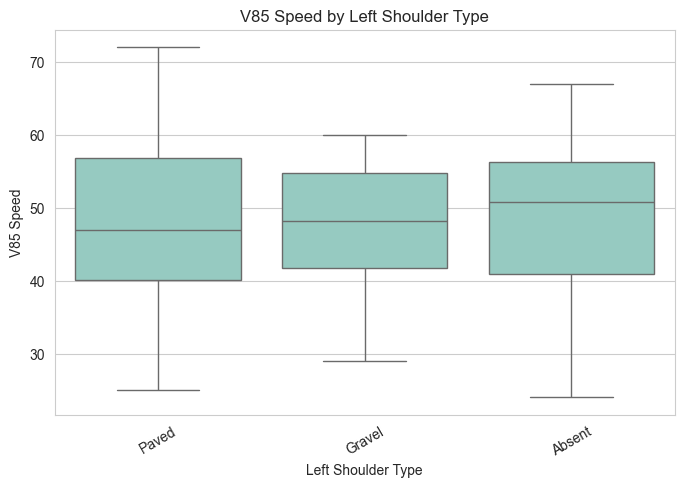

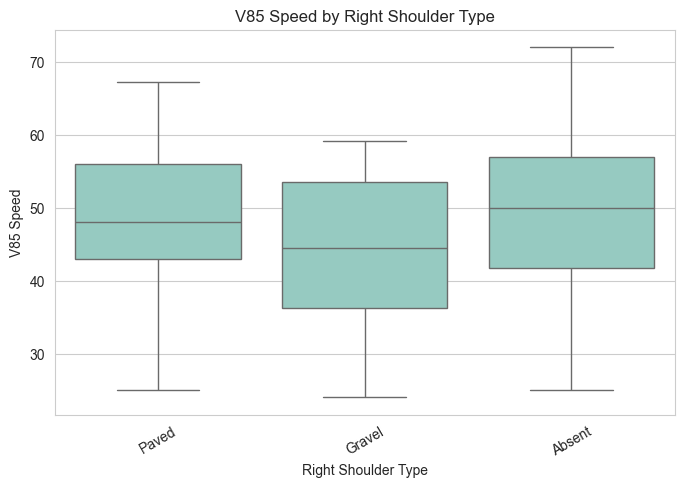

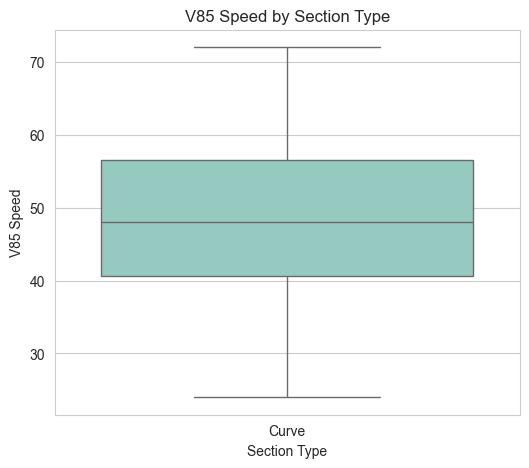

In [51]:
# Left shoulder type
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Left Shoulder Type"], y=df["V85 Speed"])
plt.title("V85 Speed by Left Shoulder Type")
plt.xticks(rotation=30)
plt.show()

# Right shoulder type
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Right Shoulder Type"], y=df["V85 Speed"])
plt.title("V85 Speed by Right Shoulder Type")
plt.xticks(rotation=30)
plt.show()

# Section type (VERY IMPORTANT)
plt.figure(figsize=(6,5))
sns.boxplot(x=df["Section Type"], y=df["V85 Speed"])
plt.title("V85 Speed by Section Type")
plt.show()

Correlation Matrix:


,V85 Speed,Gradient,Curvature,Carriageway Width,Left Shoulder Width,Right Shoulder Width
V85 Speed,1.000000,0.091917,-0.680944,0.094946,-0.035119,-0.090205
Gradient,0.091917,1.000000,0.002424,-0.094351,-0.137775,-0.135055
Curvature,-0.680944,0.002424,1.000000,-0.083379,-0.161655,0.031414
Carriageway Width,0.094946,-0.094351,-0.083379,1.000000,-0.201258,-0.267423
Left Shoulder Width,-0.035119,-0.137775,-0.161655,-0.201258,1.000000,0.491390
Right Shoulder Width,-0.090205,-0.135055,0.031414,-0.267423,0.491390,1.000000


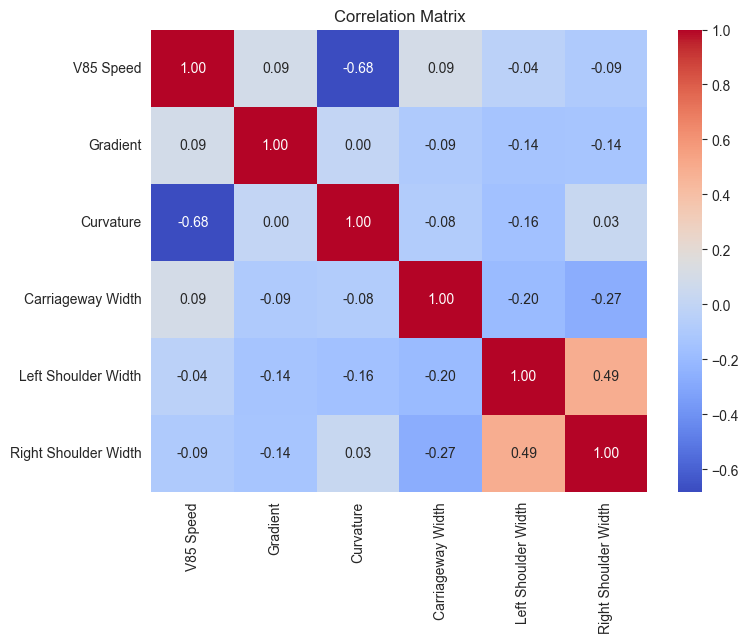

In [52]:
corr_df = df[[
    "V85 Speed",
    "Gradient",
    "Curvature",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]]

corr_matrix = corr_df.corr()

print("Correlation Matrix:")
display(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [53]:
model_df = df[[
    "SN",
    "V85 Speed",
    "Gradient",
    "Curvature",
    "Carriageway Width",
    "Left Shoulder Width",
    "Left Shoulder Type",
    "Right Shoulder Width",
    "Right Shoulder Type",
    "Section Type"
]].copy()

print("Initial model dataset:")
display(model_df.head())

Initial model dataset:


,SN,V85 Speed,Gradient,Curvature,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type,Section Type
0,1,35.00,8.540,0.033333,5.5,1.0,Paved,1.0,Paved,Curve
1,2,39.00,6.420,0.028571,5.5,1.0,Paved,1.0,Paved,Curve
2,3,37.00,2.420,0.013333,5.5,1.0,Gravel,1.0,Gravel,Curve
3,4,46.35,4.140,0.013333,5.5,1.0,Paved,1.0,Paved,Curve
4,5,40.15,5.235,0.023810,7.0,1.0,Paved,1.0,Gravel,Curve


In [54]:
model_df = pd.get_dummies(
    model_df,
    columns=["Left Shoulder Type", "Right Shoulder Type", "Section Type"],
    drop_first=True
)

print("Dataset after encoding:")
pd.set_option('display.max_columns', None)
display(model_df.head())

Dataset after encoding:


,SN,V85 Speed,Gradient,Curvature,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,Right Shoulder Type_Gravel,Right Shoulder Type_Paved
0,1,35.00,8.540,0.033333,5.5,1.0,1.0,False,True,False,True
1,2,39.00,6.420,0.028571,5.5,1.0,1.0,False,True,False,True
2,3,37.00,2.420,0.013333,5.5,1.0,1.0,True,False,True,False
3,4,46.35,4.140,0.013333,5.5,1.0,1.0,False,True,False,True
4,5,40.15,5.235,0.023810,7.0,1.0,1.0,False,True,True,False


In [55]:
X = model_df.drop(columns=["SN", "V85 Speed"])
y = model_df["V85 Speed"]

print("Predictor variables:")
display(pd.DataFrame({"Variable": X.columns}))

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Predictor variables:


,Variable
0,Gradient
1,Curvature
2,Carriageway Width
3,Left Shoulder Width
4,Right Shoulder Width
5,Left Shoulder Type_Gravel
6,Left Shoulder Type_Paved
7,Right Shoulder Type_Gravel
8,Right Shoulder Type_Paved


Shape of X: (87, 9)
Shape of y: (87,)


In [57]:
X = model_df.drop(columns=["SN", "V85 Speed"])
y = model_df["V85 Speed"]

# Convert boolean to int (VERY IMPORTANT)
X = X.astype(float)

In [58]:
X_vif = sm.add_constant(X)

vif_table = pd.DataFrame()
vif_table["Variable"] = X_vif.columns
vif_table["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("VIF Table:")
display(vif_table)

VIF Table:


,Variable,VIF
0,const,261.515894
1,Gradient,1.104320
2,Curvature,1.095640
3,Carriageway Width,1.168473
4,Left Shoulder Width,47.183531
5,Right Shoulder Width,56.491535
6,Left Shoulder Type_Gravel,24.670841
7,Left Shoulder Type_Paved,28.747578
8,Right Shoulder Type_Gravel,21.090521
9,Right Shoulder Type_Paved,34.871792


In [59]:
# Drop all shoulder type variables
X = X.drop(columns=[
    col for col in X.columns if "Shoulder Type" in col
])

In [61]:
X = X.astype(float)

X_vif = sm.add_constant(X)

vif_table = pd.DataFrame()
vif_table["Variable"] = X_vif.columns
vif_table["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

display(vif_table)

,Variable,VIF
0,const,240.889845
1,Gradient,1.048127
2,Curvature,1.054798
3,Carriageway Width,1.118795
4,Left Shoulder Width,1.403145
5,Right Shoulder Width,1.402885


In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (69, 5)
Testing data: (18, 5)


In [63]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
#MLR MODEL
mlr = LinearRegression()

mlr.fit(X_train, y_train)

y_pred_mlr = mlr.predict(X_test)

In [67]:
r2 = r2_score(y_test, y_pred_mlr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlr))
mae = mean_absolute_error(y_test, y_pred_mlr)

print("MLR Results:")
print("R2 Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

MLR Results:
R2 Score: 0.2321071273287818
RMSE: 7.612269557832606
MAE: 6.142659034940179


In [68]:
result_mlr = {
    "Model": "MLR",
    "R2": r2,
    "RMSE": rmse,
    "MAE": mae
}

In [69]:
coeff_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": mlr.coef_
})

display(coeff_df)

,Variable,Coefficient
0,Gradient,0.642830
1,Curvature,-463.234455
2,Carriageway Width,0.454519
3,Left Shoulder Width,-3.313976
4,Right Shoulder Width,1.686873


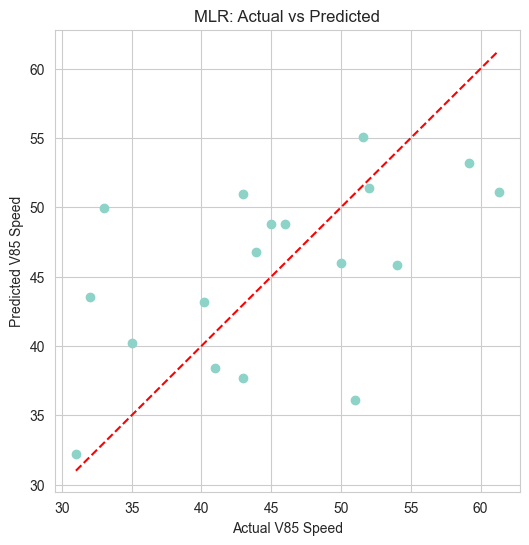

In [70]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_mlr)
plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("MLR: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

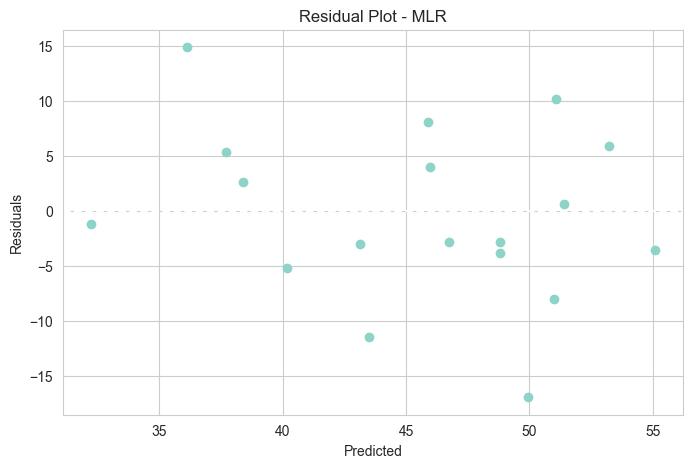

In [71]:
residuals = y_test - y_pred_mlr

plt.figure()
plt.scatter(y_pred_mlr, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot - MLR")
plt.show()

In [72]:
#RANDOM FOREST
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [73]:
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results:")
print("R2 Score:", r2_rf)
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)

Random Forest Results:
R2 Score: 0.08741064512307417
RMSE: 8.29853709440539
MAE: 6.379083333333337


In [74]:
result_rf = {
    "Model": "Random Forest",
    "R2": r2_rf,
    "RMSE": rmse_rf,
    "MAE": mae_rf
}

In [75]:
importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance_df)

,Variable,Importance
1,Curvature,0.575633
0,Gradient,0.334544
3,Left Shoulder Width,0.044623
4,Right Shoulder Width,0.036058
2,Carriageway Width,0.009141


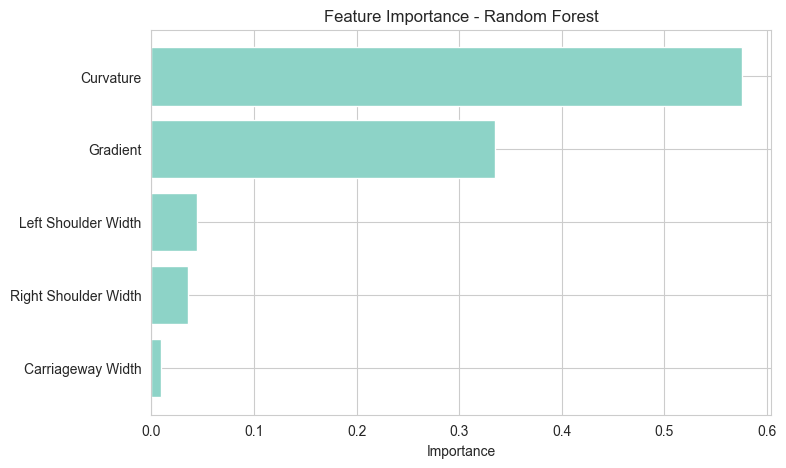

In [76]:
plt.figure(figsize=(8,5))
plt.barh(importance_df["Variable"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

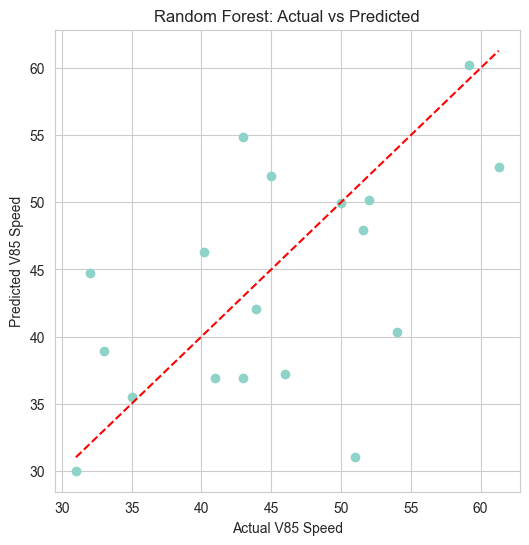

In [77]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Random Forest: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [78]:
#HYPERPARAMETER TUNING
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

rf_cv = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_cv.fit(X_train, y_train)

best_rf = rf_cv.best_estimator_

print("Best Parameters:", rf_cv.best_params_)

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [79]:
y_pred_rf_tuned = best_rf.predict(X_test)

r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)

print("Tuned RF Results:")
print("R2 Score:", r2_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("MAE:", mae_rf_tuned)

Tuned RF Results:
R2 Score: 0.13067164104915474
RMSE: 8.099454387343933
MAE: 6.1138238284248025


In [80]:
#XG BOOST MODEL
xgb = XGBRegressor(random_state=42)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [81]:
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("XGBoost Results:")
print("R2 Score:", r2_xgb)
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)

XGBoost Results:
R2 Score: -0.08725724288055003
RMSE: 9.057951585968974
MAE: 6.975361612108018


In [82]:
importance_xgb = pd.DataFrame({
    "Variable": X.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance_xgb)

,Variable,Importance
1,Curvature,0.730613
3,Left Shoulder Width,0.101785
0,Gradient,0.085882
2,Carriageway Width,0.061317
4,Right Shoulder Width,0.020403


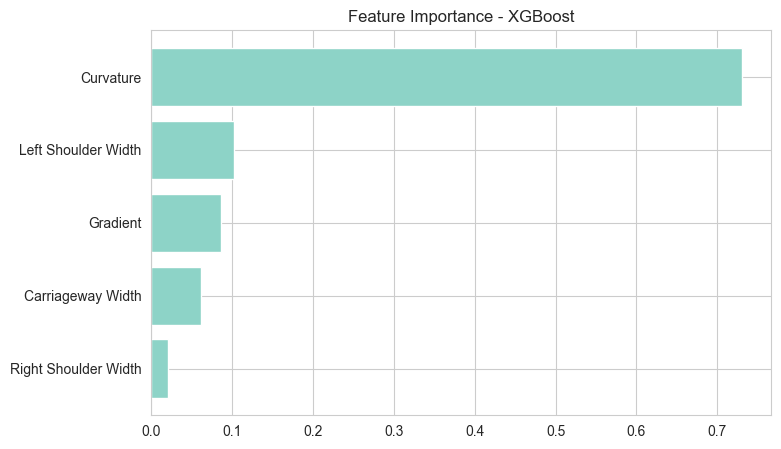

In [83]:
plt.figure(figsize=(8,5))
plt.barh(importance_xgb["Variable"], importance_xgb["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.show()

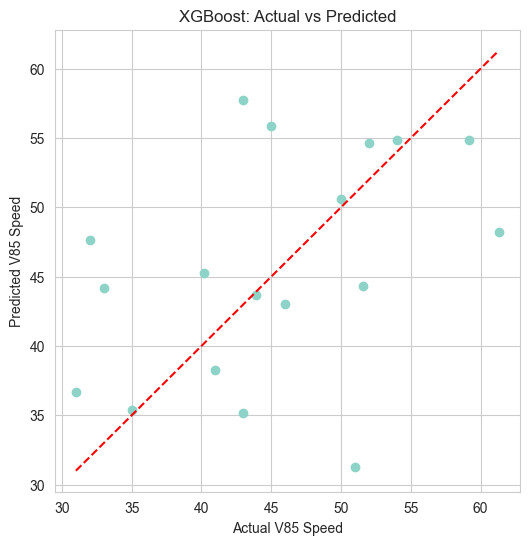

In [84]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("XGBoost: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [85]:
#TUNED XGBOOST
param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)

xgb_cv = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xgb_cv.fit(X_train, y_train)

best_xgb = xgb_cv.best_estimator_

print("Best Parameters:", xgb_cv.best_params_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50, 'subsample': 1.0}


In [86]:
y_pred_xgb_tuned = best_xgb.predict(X_test)

r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)

print("Tuned XGBoost Results:")
print("R2 Score:", r2_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("MAE:", mae_xgb_tuned)

Tuned XGBoost Results:
R2 Score: 0.1099730990815162
RMSE: 8.195310395508582
MAE: 6.475773578219944


In [87]:
#SVR MODEL
X_train_scaled
X_test_scaled

array([[-1.19011656,  1.17939992,  0.28625572,  0.01775272, -1.11547297],
       [ 2.08361855,  1.17939992, -3.00568505,  1.24269057,  1.27112036],
       [-1.08781233,  1.00701816,  0.28625572,  1.24269057,  1.27112036],
       [ 1.08059238, -0.32448237, -3.00568505,  1.24269057,  1.27112036],
       [-1.6705016 , -0.1996542 , -3.00568505,  1.24269057,  1.27112036],
       [-0.64301137, -0.52717955,  0.28625572,  0.63022165, -1.11547297],
       [ 0.10647826, -0.14793967,  0.28625572,  1.24269057,  1.27112036],
       [ 0.3533428 ,  0.54733345,  0.28625572,  1.24269057,  1.27112036],
       [ 0.61355136,  0.63762866,  0.28625572,  1.24269057,  1.27112036],
       [-0.26048254,  2.12749963,  0.28625572, -1.20718513,  0.0778237 ],
       [-1.4392051 , -0.71679949, -1.90837146, -1.20718513,  0.0778237 ],
       [-1.28574876, -0.71679949,  0.28625572,  0.01775272, -1.11547297],
       [ 1.30966487, -0.40076626,  0.28625572, -1.20718513,  0.0778237 ],
       [-1.13229243,  0.90851429,  0.2

In [88]:
svr = SVR()

svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

In [89]:
r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("SVR Results:")
print("R2 Score:", r2_svr)
print("RMSE:", rmse_svr)
print("MAE:", mae_svr)

SVR Results:
R2 Score: 0.05279048823209764
RMSE: 8.45447930941174
MAE: 7.068038228840346


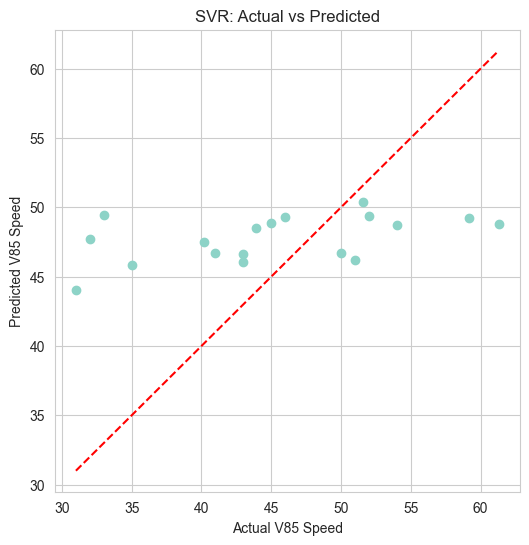

In [90]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("SVR: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [91]:
param_grid_svr = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.1, 0.5, 1],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"]
}

svr = SVR()

svr_cv = GridSearchCV(
    svr,
    param_grid_svr,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

svr_cv.fit(X_train_scaled, y_train)

best_svr = svr_cv.best_estimator_

print("Best Parameters:", svr_cv.best_params_)

Best Parameters: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [92]:
y_pred_svr_tuned = best_svr.predict(X_test_scaled)

r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)
rmse_svr_tuned = np.sqrt(mean_squared_error(y_test, y_pred_svr_tuned))
mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)

print("Tuned SVR Results:")
print("R2 Score:", r2_svr_tuned)
print("RMSE:", rmse_svr_tuned)
print("MAE:", mae_svr_tuned)

Tuned SVR Results:
R2 Score: 0.2920918915078867
RMSE: 7.308904440408708
MAE: 5.650920790440308


In [93]:
#ANN MODEL
ann = MLPRegressor(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    max_iter=3000,
    random_state=42
)

ann.fit(X_train_scaled, y_train)

y_pred_ann = ann.predict(X_test_scaled)

D:\Thesis_Speed_Model\env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [94]:
r2_ann = r2_score(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
mae_ann = mean_absolute_error(y_test, y_pred_ann)

print("ANN Results:")
print("R2 Score:", r2_ann)
print("RMSE:", rmse_ann)
print("MAE:", mae_ann)

ANN Results:
R2 Score: -0.660215635254211
RMSE: 11.192989339814924
MAE: 7.875365779991786


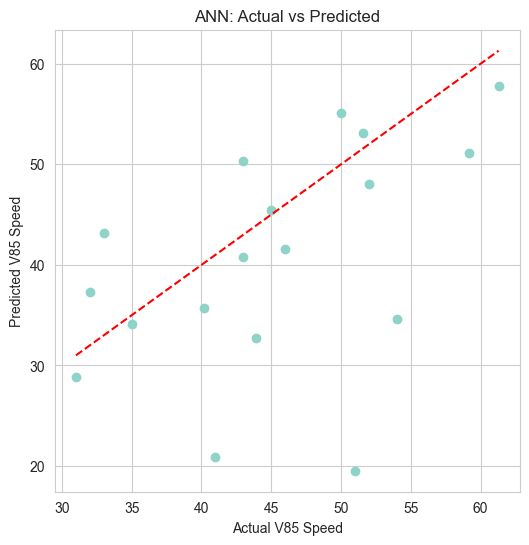

In [95]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_ann)
plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("ANN: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.show()

In [96]:
param_grid_ann = {
    "hidden_layer_sizes": [(8,), (16,), (16, 8)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.01]
}

In [97]:
ann = MLPRegressor(
    solver="adam",
    max_iter=5000,
    early_stopping=True,
    random_state=42
)

In [98]:
ann_cv = GridSearchCV(
    ann,
    param_grid_ann,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ann_cv.fit(X_train_scaled, y_train)

best_ann = ann_cv.best_estimator_

print("Best Parameters:", ann_cv.best_params_)

Best Parameters: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (8,), 'learning_rate_init': 0.01}


In [99]:
y_pred_ann_tuned = best_ann.predict(X_test_scaled)

r2_ann_tuned = r2_score(y_test, y_pred_ann_tuned)
rmse_ann_tuned = np.sqrt(mean_squared_error(y_test, y_pred_ann_tuned))
mae_ann_tuned = mean_absolute_error(y_test, y_pred_ann_tuned)

print("Tuned ANN Results:")
print("R2 Score:", r2_ann_tuned)
print("RMSE:", rmse_ann_tuned)
print("MAE:", mae_ann_tuned)

Tuned ANN Results:
R2 Score: -0.16373641329476118
RMSE: 9.371112511964247
MAE: 7.822339689745885


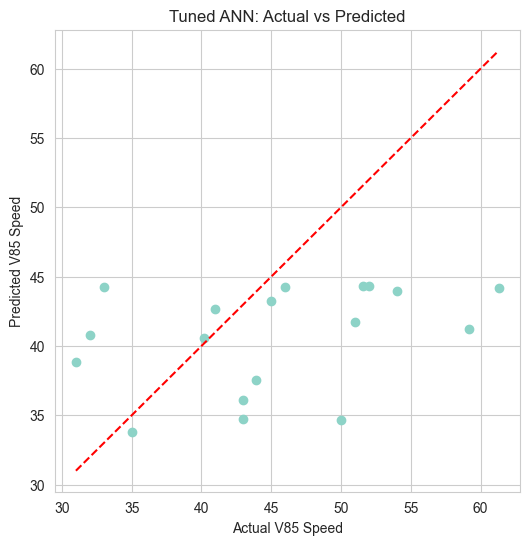

In [100]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ann_tuned)
plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned ANN: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.show()

In [101]:
results_df = pd.DataFrame([
    {"Model": "Multiple Linear Regression (MLR)", "R2": 0.232, "RMSE": 7.61, "MAE": 6.14},
    {"Model": "Random Forest (Tuned)", "R2": 0.13, "RMSE": 8.09, "MAE": 6.40},
    {"Model": "XGBoost (Tuned)", "R2": 0.11, "RMSE": 8.19, "MAE": 6.48},
    {"Model": "Support Vector Regression (SVR - Tuned)", "R2": 0.292, "RMSE": 7.31, "MAE": 5.65},
    {"Model": "Artificial Neural Network (ANN - Tuned)", "R2": -0.164, "RMSE": 9.37, "MAE": 7.82}
])

# Sort by R2 (best first)
results_df = results_df.sort_values(by="R2", ascending=False)

display(results_df)

,Model,R2,RMSE,MAE
3,Support Vector Regression (SVR - Tuned),0.292,7.31,5.65
0,Multiple Linear Regression (MLR),0.232,7.61,6.14
1,Random Forest (Tuned),0.130,8.09,6.40
2,XGBoost (Tuned),0.110,8.19,6.48
4,Artificial Neural Network (ANN - Tuned),-0.164,9.37,7.82
